## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Yorleny Aguillar, Nicolle Rodriguez, Juan Jose Garcia" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Una bodega necesita optimizar la organización y búsqueda de los códigos numéricos de sus productos, los cuales ingresan al sistema en un orden completamente aleatorio.

El objetivo es comparar el rendimiento estructural de dos estructuras de datos: un Árbol Binario de Búsqueda (BST) tradicional y un Árbol AVL. El problema radica en que, dependiendo del orden de llegada de los códigos, el BST puede degenerar y perder eficiencia en las búsquedas, mientras que el AVL debe auto-balancearse mediante rotaciones matemáticas para garantizar un tiempo de búsqueda óptimo. El sistema debe permitir insertar los datos, calcular factores de balance, aplicar rotaciones simples y dobles, y validar la estructura final utilizando recorridos en preorden, inorden y postorden.



## 2) Requerimientos **[2 pts]**

## **Requerimientos Funcionales:**

 **RF01:** El sistema debe permitir al usuario ingresar por teclado la cantidad exacta de productos ($n$) a registrar.

**RF02:** El sistema debe capturar $n$ códigos numéricos enteros y almacenarlos en una lista inicial.

**RF03:** El sistema debe construir un BST insertando los códigos estrictamente en su orden de llegada, cumpliendo la regla de menores a la izquierda y mayores a la derecha.

**RF04:** El sistema debe construir un AVL insertando los mismos códigos, calculando el factor de balance $altura(izq) - altura(der)$ en cada nodo.

**RF05:** El sistema debe ejecutar rotaciones (simples a la derecha/izquierda o dobles) automáticamente si un nodo en el AVL detecta un desbalance fuera del rango [-1, 1].

**RF06:** El sistema debe calcular y mostrar los recorridos preorden, inorden y postorden para ambos árboles de forma recursiva.

## **Requerimientos No Funcionales:**

**RNF01:** La lógica de inserción, los recorridos y el balanceo deben implementarse de forma 100% manual, sin utilizar librerías externas que resuelvan la estructura de datos.

**RNF02:** El código debe estar escrito en Python y ser ejecutable en un entorno de notebooks (Jupyter/Colab).

**RNF03:** La interfaz visual debe utilizar una librería gráfica (como networkx y matplotlib) para dibujar con claridad los nodos y conexiones, o generar una salida estructurada por consola.



## 3) Historias de usuario **[2 pts]**

Historia 1: Registro de códigos baseComo analista de inventarios,quiero ingresar la cantidad de productos y sus respectivos códigos numéricos al sistema,para tener la lista inicial de datos sobre la cual construir los árboles.


Criterios de aceptación: El programa solicita la cantidad $n$.El programa itera $n$ veces pidiendo un código numérico.Los valores se almacenan en una variable tipo lista en Python.

Historia 2: Construcción y balanceo del AVLComo arquitecto del sistema,quiero que el árbol AVL calcule su factor de balance en cada inserción,para asegurar que la estructura siempre esté optimizada para búsquedas rápidas.

Criterios de aceptación: Cada vez que se inserta un nodo, se evalúa $altura(izq) - altura(der)$.Si el factor de balance es mayor a 1 o menor a -1, se dispara la función de rotación correspondiente.El árbol resultante mantiene una diferencia de alturas máxima de 1 entre sus subárboles.

Historia 3: Auditoría visual mediante recorridosComo auditor de la base de datos,quiero ver los datos del sistema usando recorridos Inorden, Preorden y Postorden,para validar que los punteros y conexiones de la jerarquía se formaron sin errores.

*Criterios de aceptación:*Los recorridos utilizan funciones recursivas.El recorrido inorden del BST y del AVL imprime la lista ordenada de menor a mayor obligatoriamente.

## 4) Diagramas de flujo **[5 pts]**
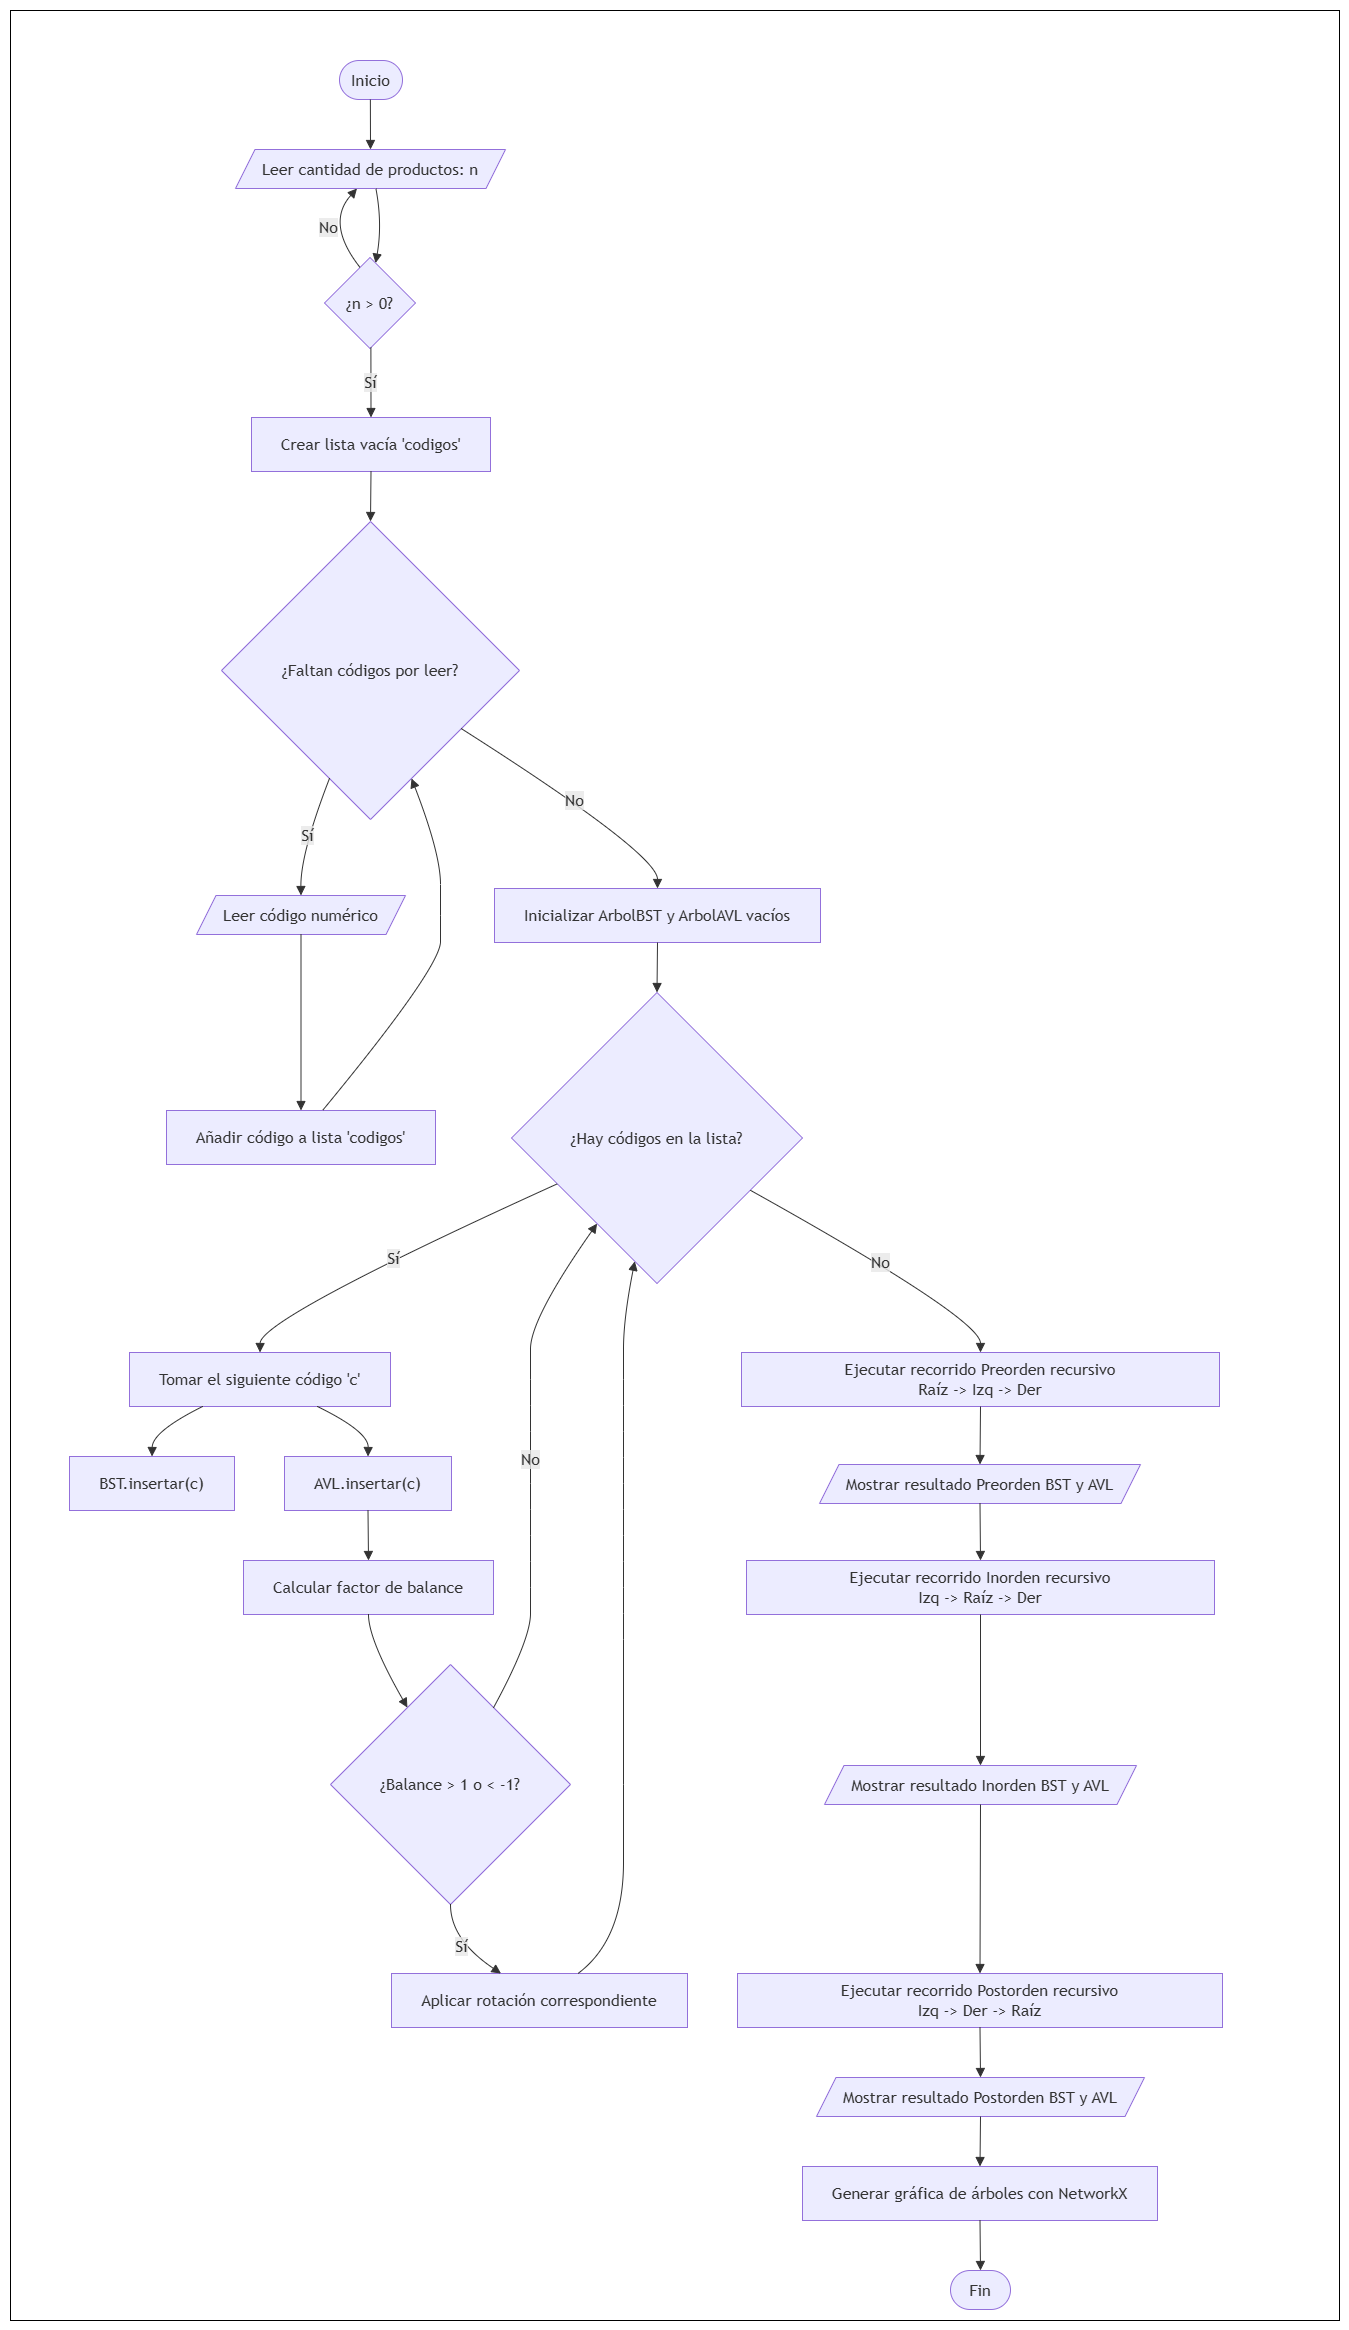

### 5) Análisis de complejidad **[15 pts]**
**Justificación:** El tiempo de búsqueda e inserción en un árbol binario depende directamente de su altura ($h$). En un BST, si los códigos ingresan en orden (ej. 1, 2, 3, 4), el árbol no se divide, sino que crece en línea recta como una lista enlazada, haciendo que $h = n$. En el AVL, las rotaciones reacomodan los nodos para que estén lo más agrupados posible hacia la raíz, garantizando que la altura siempre se mantenga cercana al logaritmo en base 2 de la cantidad de elementos.

**Función T[n]:**

Para el BST (Peor caso): $T(n) = T(n-1) + c  ==> O(n)$

Para el AVL (Cualquier caso): $T(n) = T(n/2) + c ==> O(\log n)$

**Mejor y peor caso:**

Mejor caso (Para ambos): $O(\log n)$.
 Ocurre cuando los datos de entrada llegan en un orden que mágicamente los distribuye de forma perfecta. En una gráfica, esto se dibuja como una curva logarítmica que se aplana rápido (crecimiento muy lento).

 Peor caso: En el BST es $O(n)$ (tiempo lineal, una línea recta en diagonal hacia arriba en la gráfica). En el AVL, el peor caso sigue siendo estrictamente $O(\log n)$ gracias al costo constante $O(1)$ de las rotaciones tras la inserción.

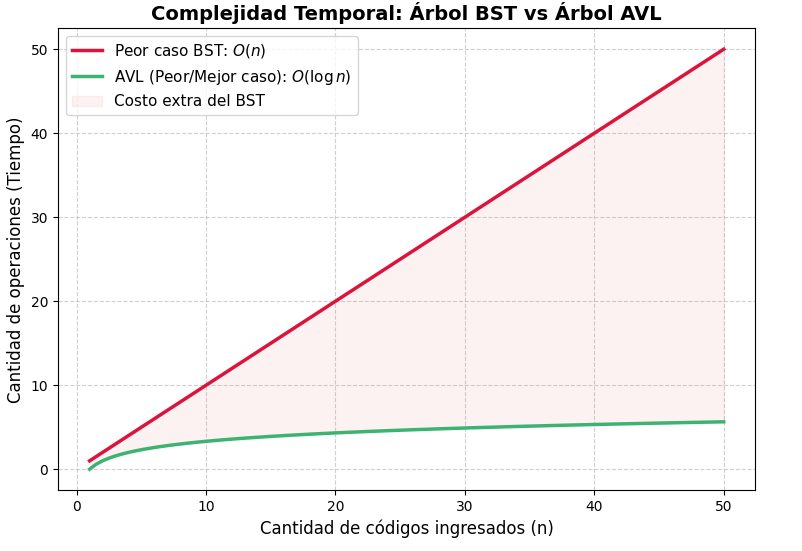

## 6) Código funcional **[15 pts]**


Ingrese la cantidad de productos: 3
Ingrese el código 1: 65426
Ingrese el código 2: 765357
Ingrese el código 3: 97632

codigos = [65426, 765357, 97632]

ÁRBOL BINARIO DE BÚSQUEDA (BST)
Preorden:  [65426, 765357, 97632]
Inorden:   [65426, 97632, 765357]
Postorden: [97632, 765357, 65426]

ÁRBOL AVL (BALANCEADO)
Preorden:  [97632, 65426, 765357]
Inorden:   [65426, 97632, 765357]
Postorden: [65426, 765357, 97632]


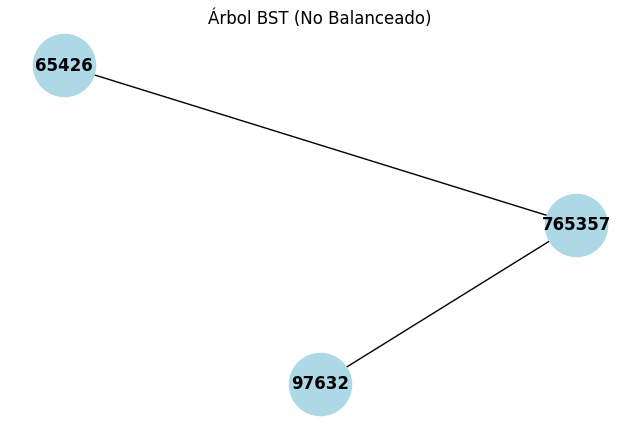

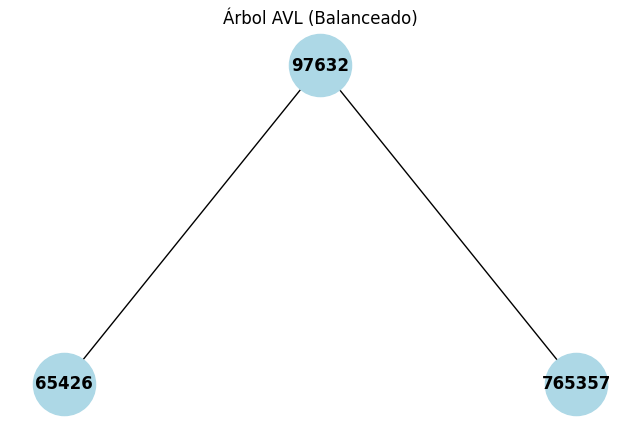

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

class Nodo:
    def __init__(self, valor):
        self.valor = valor
        self.izq = None
        self.der = None
        self.altura = 1

class ArbolBST:
    def __init__(self):
        self.raiz = None

    def insertar(self, valor):
        self.raiz = self._insertar_recursivo(self.raiz, valor)

    def _insertar_recursivo(self, nodo, valor):
        if nodo is None: return Nodo(valor)
        if valor < nodo.valor:
            nodo.izq = self._insertar_recursivo(nodo.izq, valor)
        elif valor > nodo.valor:
            nodo.der = self._insertar_recursivo(nodo.der, valor)
        return nodo

class ArbolAVL:
    def __init__(self):
        self.raiz = None

    def altura(self, nodo):
        if not nodo: return 0
        return nodo.altura

    def balance(self, nodo):
        if not nodo: return 0
        return self.altura(nodo.izq) - self.altura(nodo.der)

    def rotacion_der(self, y):
        x = y.izq
        T2 = x.der
        x.der = y
        y.izq = T2
        y.altura = 1 + max(self.altura(y.izq), self.altura(y.der))
        x.altura = 1 + max(self.altura(x.izq), self.altura(x.der))
        return x

    def rotacion_izq(self, x):
        y = x.der
        T2 = y.izq
        y.izq = x
        x.der = T2
        x.altura = 1 + max(self.altura(x.izq), self.altura(x.der))
        y.altura = 1 + max(self.altura(y.izq), self.altura(y.der))
        return y

    def insertar(self, valor):
        self.raiz = self._insertar_recursivo(self.raiz, valor)

    def _insertar_recursivo(self, nodo, valor):
        if not nodo: return Nodo(valor)
        elif valor < nodo.valor:
            nodo.izq = self._insertar_recursivo(nodo.izq, valor)
        else:
            nodo.der = self._insertar_recursivo(nodo.der, valor)

        nodo.altura = 1 + max(self.altura(nodo.izq), self.altura(nodo.der))
        b = self.balance(nodo)

        if b > 1 and valor < nodo.izq.valor:
            return self.rotacion_der(nodo)
        if b < -1 and valor > nodo.der.valor:
            return self.rotacion_izq(nodo)
        if b > 1 and valor > nodo.izq.valor:
            nodo.izq = self.rotacion_izq(nodo.izq)
            return self.rotacion_der(nodo)
        if b < -1 and valor < nodo.der.valor:
            nodo.der = self.rotacion_der(nodo.der)
            return self.rotacion_izq(nodo)
        return nodo

# ----------------- RECORRIDOS -----------------
def preorden(nodo, res):
    if nodo:
        res.append(nodo.valor)
        preorden(nodo.izq, res)
        preorden(nodo.der, res)

def inorden(nodo, res):
    if nodo:
        inorden(nodo.izq, res)
        res.append(nodo.valor)
        inorden(nodo.der, res)

def postorden(nodo, res):
    if nodo:
        postorden(nodo.izq, res)
        postorden(nodo.der, res)
        res.append(nodo.valor)

# ----------------- GRAFICACIÓN -----------------
def graficar_arbol(raiz, titulo):
    if not raiz:
        print(f"El árbol '{titulo}' está vacío.")
        return

    G = nx.DiGraph()
    pos = {}

    def construir_grafo(nodo, x, y, dx):
        if nodo:
            G.add_node(nodo.valor)
            pos[nodo.valor] = (x, y)
            if nodo.izq:
                G.add_edge(nodo.valor, nodo.izq.valor)
                construir_grafo(nodo.izq, x - dx, y - 1, dx / 2)
            if nodo.der:
                G.add_edge(nodo.valor, nodo.der.valor)
                construir_grafo(nodo.der, x + dx, y - 1, dx / 2)

    construir_grafo(raiz, 0, 0, 2)
    plt.figure(figsize=(8, 5))
    plt.title(titulo)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_weight="bold", arrows=False)
    plt.show()


while True:
    try:
        entrada_n = input("Ingrese la cantidad de productos: ")
        n = int(entrada_n)
        if n <= 0:
            print("Por favor, ingrese un número mayor a cero.")
            continue
        break
    except ValueError:
        print("Error: Debe ingresar un número entero válido. No se permiten letras ni símbolos.")

codigos = []

for i in range(n):
    while True:
        try:
            entrada_codigo = input(f"Ingrese el código {i+1}: ")
            codigo = int(entrada_codigo)
            codigos.append(codigo)
            break
        except ValueError:
            print(f" Error: El código debe ser un número entero. Intente ingresar el código {i+1} nuevamente.")

print(f"\ncodigos = {codigos}\n")

bst = ArbolBST()
avl = ArbolAVL()

for c in codigos:
    bst.insertar(c)
    avl.insertar(c)

print("=" * 40)
print("ÁRBOL BINARIO DE BÚSQUEDA (BST)")
print("=" * 40)
res_pre, res_in, res_post = [], [], []
preorden(bst.raiz, res_pre)
inorden(bst.raiz, res_in)
postorden(bst.raiz, res_post)
print(f"Preorden:  {res_pre}")
print(f"Inorden:   {res_in}")
print(f"Postorden: {res_post}")

print("\n" + "=" * 40)
print("ÁRBOL AVL (BALANCEADO)")
print("=" * 40)
res_pre_avl, res_in_avl, res_post_avl = [], [], []
preorden(avl.raiz, res_pre_avl)
inorden(avl.raiz, res_in_avl)
postorden(avl.raiz, res_post_avl)
print(f"Preorden:  {res_pre_avl}")
print(f"Inorden:   {res_in_avl}")
print(f"Postorden: {res_post_avl}")

graficar_arbol(bst.raiz, "Árbol BST (No Balanceado)")
graficar_arbol(avl.raiz, "Árbol AVL (Balanceado)")

## 7) Tests aplicados **[15 pts]**

In [4]:

bst_test = ArbolBST()
avl_test = ArbolAVL()
for c in [30, 20, 10, 25, 28, 27, 5, 50]:
    bst_test.insertar(c)
    avl_test.insertar(c)

res_in_test = []
inorden(bst_test.raiz, res_in_test)
assert res_in_test == [5, 10, 20, 25, 27, 28, 30, 50], "Error en inorden del BST"

res_in_avl_test = []
inorden(avl_test.raiz, res_in_avl_test)
assert res_in_avl_test == [5, 10, 20, 25, 27, 28, 30, 50], "Error en inorden del AVL"

assert avl_test.raiz.valor == 25, "Error de balanceo: La raíz del AVL debería ser 25"

res_pre_avl = []
preorden(avl_test.raiz, res_pre_avl)
assert res_pre_avl == [25, 10, 5, 20, 28, 27, 30, 50], "Error en el preorden del AVL o rotaciones incompletas"

print("¡Todos los tests pasaron correctamente!")


¡Todos los tests pasaron correctamente!
